In [1]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
embeding_sample = pd.read_parquet('./results/HomoSapiens.TRB.GILGFVFTL_sample_embeddings.parquet')
embeding_sample

FileNotFoundError: [Errno 2] No such file or directory: './results/HomoSapiens.TRB.GILGFVFTL_sample_embeddings.parquet'

In [ ]:
data_initial = pd.read_csv('./vdjdb_export/HomoSapiens.TRB.GILGFVFTL.txt', sep='\t')
data_initial

In [6]:
res_mine = pd.read_csv('./results/HomoSapiens.TRB.GILGFVFTL_enriched_clonotypes_tcremp.tsv',sep='\t')

res_mine = res_mine[res_mine.source == 'sample']
clusters_statuses = pd.read_csv('./results/HomoSapiens.TRB.GILGFVFTL_summary_tcrempnet.tsv', sep='\t')

res_mine = res_mine.merge(clusters_statuses[['log_fold_change', 'cluster_id']], on='cluster_id')

res_mine = res_mine[res_mine.log_fold_change >0]

res_mine

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom,log_fold_change
0,s_0,0,CAAATGLYGYTF,TRBV19*01,TRBJ1-2*01,sample,0.0,2.225000
1,s_4,0,CAASTGIYGYTF,TRBV19*01,TRBJ1-2*01,sample,0.0,2.225000
2,s_5,0,CAASTGNYGYTF,TRBV19*01,TRBJ1-2*01,sample,0.0,2.225000
3,s_6,0,CAASTGSYGYTF,TRBV19*01,TRBJ1-2*01,sample,0.0,2.225000
4,s_7,0,CAASTGVLGYTF,TRBV19*01,TRBJ1-2*01,sample,0.0,2.225000
...,...,...,...,...,...,...,...,...
3526,s_4911,6649,CSAPGGPNKNTGELFF,TRBV20-1*01,TRBJ2-2*01,sample,0.0,2.314291
3553,s_4953,6542,CSARDPGQLVSGNTIYF,TRBV20-1*01,TRBJ1-3*01,sample,0.0,2.013261
3554,s_5000,7773,CSARGGDSVLRVGEQYF,TRBV20-1*01,TRBJ2-7*01,sample,0.0,2.138200
3562,s_5095,4969,CSGAGVVAGGFNTGELFF,TRBV29-1*01,TRBJ2-2*01,sample,0.0,2.138200


In [7]:
data_initial = data_initial[data_initial.junction_aa.apply(len) < 30]

In [8]:
data_initial = data_initial.reset_index().drop('index', axis=1)

In [9]:
data_concated = pd.concat([data_initial, embeding_sample], axis=1)
data_concated

,junction_aa,v_call,j_call,locus,0_b_v,0_b_j,0_b_cdr3,1_b_v,1_b_j,1_b_cdr3,...,2996_b_cdr3,2997_b_v,2997_b_j,2997_b_cdr3,2998_b_v,2998_b_j,2998_b_cdr3,2999_b_v,2999_b_j,2999_b_cdr3
0,CAAATGLYGYTF,TRBV19*01,TRBJ1-2*01,beta,504.0,221.0,1550.0,456.0,198.0,700.0,...,920.0,663.0,198.0,800.0,684.0,197.0,1260.0,516.0,197.0,710.0
1,CAAPLGSNQPQHF,TRBV28*01,TRBJ1-5*01,beta,486.0,0.0,1140.0,364.0,221.0,970.0,...,990.0,665.0,221.0,870.0,720.0,196.0,1510.0,542.0,196.0,900.0
2,CAASGRASETQYF,TRBV19*01,TRBJ2-5*01,beta,504.0,223.0,1180.0,456.0,198.0,810.0,...,870.0,663.0,198.0,850.0,684.0,197.0,1150.0,516.0,197.0,740.0
3,CAASSRSTDTQYF,TRBV19*01,TRBJ2-3*01,beta,504.0,212.0,1280.0,456.0,213.0,830.0,...,910.0,663.0,213.0,830.0,684.0,202.0,1210.0,516.0,202.0,700.0
4,CAASTGIYGYTF,TRBV19*01,TRBJ1-2*01,beta,504.0,221.0,1490.0,456.0,198.0,680.0,...,960.0,663.0,198.0,740.0,684.0,197.0,1280.0,516.0,197.0,730.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5229,CVSSIRSAYEQYF,TRBV19*01,TRBJ2-7*01,beta,504.0,221.0,1380.0,456.0,0.0,550.0,...,1130.0,663.0,0.0,510.0,684.0,107.0,1290.0,516.0,107.0,680.0
5230,CVSSIRSSYEQYF,TRBV19*01,TRBJ2-7*01,beta,504.0,221.0,1380.0,456.0,0.0,570.0,...,1130.0,663.0,0.0,570.0,684.0,107.0,1310.0,516.0,107.0,680.0
5231,CVSSLYSNQPQHF,TRBV19*01,TRBJ1-5*01,beta,504.0,0.0,1060.0,456.0,221.0,770.0,...,1110.0,663.0,221.0,750.0,684.0,196.0,1410.0,516.0,196.0,760.0
5232,CVSSVRSSYEQYF,TRBV19*01,TRBJ2-7*01,beta,504.0,221.0,1360.0,456.0,0.0,590.0,...,1110.0,663.0,0.0,550.0,684.0,107.0,1310.0,516.0,107.0,660.0


In [11]:
clusterd_dict = res_mine.set_index('cdr3aa_beta').cluster_id.to_dict()
data_concated['cluster_id'] = data_concated.junction_aa.map(clusterd_dict)
data_concated.cluster_id = (data_concated.cluster_id +1).apply(lambda x: x if pd.isnull(x) else str(int(x)))

data_concated

,junction_aa,v_call,j_call,locus,0_b_v,0_b_j,0_b_cdr3,1_b_v,1_b_j,1_b_cdr3,...,2997_b_v,2997_b_j,2997_b_cdr3,2998_b_v,2998_b_j,2998_b_cdr3,2999_b_v,2999_b_j,2999_b_cdr3,cluster_id
0,CAAATGLYGYTF,TRBV19*01,TRBJ1-2*01,beta,504.0,221.0,1550.0,456.0,198.0,700.0,...,663.0,198.0,800.0,684.0,197.0,1260.0,516.0,197.0,710.0,1
1,CAAPLGSNQPQHF,TRBV28*01,TRBJ1-5*01,beta,486.0,0.0,1140.0,364.0,221.0,970.0,...,665.0,221.0,870.0,720.0,196.0,1510.0,542.0,196.0,900.0,NaN
2,CAASGRASETQYF,TRBV19*01,TRBJ2-5*01,beta,504.0,223.0,1180.0,456.0,198.0,810.0,...,663.0,198.0,850.0,684.0,197.0,1150.0,516.0,197.0,740.0,3
3,CAASSRSTDTQYF,TRBV19*01,TRBJ2-3*01,beta,504.0,212.0,1280.0,456.0,213.0,830.0,...,663.0,213.0,830.0,684.0,202.0,1210.0,516.0,202.0,700.0,4
4,CAASTGIYGYTF,TRBV19*01,TRBJ1-2*01,beta,504.0,221.0,1490.0,456.0,198.0,680.0,...,663.0,198.0,740.0,684.0,197.0,1280.0,516.0,197.0,730.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5229,CVSSIRSAYEQYF,TRBV19*01,TRBJ2-7*01,beta,504.0,221.0,1380.0,456.0,0.0,550.0,...,663.0,0.0,510.0,684.0,107.0,1290.0,516.0,107.0,680.0,10
5230,CVSSIRSSYEQYF,TRBV19*01,TRBJ2-7*01,beta,504.0,221.0,1380.0,456.0,0.0,570.0,...,663.0,0.0,570.0,684.0,107.0,1310.0,516.0,107.0,680.0,10
5231,CVSSLYSNQPQHF,TRBV19*01,TRBJ1-5*01,beta,504.0,0.0,1060.0,456.0,221.0,770.0,...,663.0,221.0,750.0,684.0,196.0,1410.0,516.0,196.0,760.0,11
5232,CVSSVRSSYEQYF,TRBV19*01,TRBJ2-7*01,beta,504.0,221.0,1360.0,456.0,0.0,590.0,...,663.0,0.0,550.0,684.0,107.0,1310.0,516.0,107.0,660.0,10


In [12]:
data_concated_to_pca = data_concated.iloc[:, 4:-1]

data_concated_to_pca

,0_b_v,0_b_j,0_b_cdr3,1_b_v,1_b_j,1_b_cdr3,2_b_v,2_b_j,2_b_cdr3,3_b_v,...,2996_b_cdr3,2997_b_v,2997_b_j,2997_b_cdr3,2998_b_v,2998_b_j,2998_b_cdr3,2999_b_v,2999_b_j,2999_b_cdr3
0,504.0,221.0,1550.0,456.0,198.0,700.0,732.0,221.0,1170.0,732.0,...,920.0,663.0,198.0,800.0,684.0,197.0,1260.0,516.0,197.0,710.0
1,486.0,0.0,1140.0,364.0,221.0,970.0,760.0,0.0,660.0,760.0,...,990.0,665.0,221.0,870.0,720.0,196.0,1510.0,542.0,196.0,900.0
2,504.0,223.0,1180.0,456.0,198.0,810.0,732.0,223.0,900.0,732.0,...,870.0,663.0,198.0,850.0,684.0,197.0,1150.0,516.0,197.0,740.0
3,504.0,212.0,1280.0,456.0,213.0,830.0,732.0,212.0,1020.0,732.0,...,910.0,663.0,213.0,830.0,684.0,202.0,1210.0,516.0,202.0,700.0
4,504.0,221.0,1490.0,456.0,198.0,680.0,732.0,221.0,1170.0,732.0,...,960.0,663.0,198.0,740.0,684.0,197.0,1280.0,516.0,197.0,730.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5229,504.0,221.0,1380.0,456.0,0.0,550.0,732.0,221.0,1160.0,732.0,...,1130.0,663.0,0.0,510.0,684.0,107.0,1290.0,516.0,107.0,680.0
5230,504.0,221.0,1380.0,456.0,0.0,570.0,732.0,221.0,1100.0,732.0,...,1130.0,663.0,0.0,570.0,684.0,107.0,1310.0,516.0,107.0,680.0
5231,504.0,0.0,1060.0,456.0,221.0,770.0,732.0,0.0,780.0,732.0,...,1110.0,663.0,221.0,750.0,684.0,196.0,1410.0,516.0,196.0,760.0
5232,504.0,221.0,1360.0,456.0,0.0,590.0,732.0,221.0,1080.0,732.0,...,1110.0,663.0,0.0,550.0,684.0,107.0,1310.0,516.0,107.0,660.0


In [14]:
pca = PCA(n_components=50)

pca_res = pca.fit_transform(data_concated_to_pca)
pca_res = pd.DataFrame(pca_res)

pca_res

array([[ -3336.4595  ,  -2888.0557  ,  -1008.32465 , ...,    118.23431 ,
           296.78143 ,   -137.09453 ],
       [ -2471.1328  ,  -4416.766   ,   -524.48834 , ...,     71.52141 ,
           602.46246 ,    397.0486  ],
       [ -7519.847   ,   -253.82878 ,     60.885963, ...,    396.5149  ,
           478.2431  ,   -531.8526  ],
       ...,
       [ -4359.202   ,  -2836.61    ,     26.891312, ...,     85.04379 ,
           -19.58577 ,    356.256   ],
       [ -9205.505   ,   1220.3966  ,   -614.7585  , ...,     33.809196,
          -608.6005  ,    104.975586],
       [ 14136.944   , -14589.965   ,    635.47906 , ...,   1821.666   ,
           204.02568 ,    272.6695  ]], dtype=float32)

In [17]:
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,early_exaggeration=12)

tsne_res = tsne.fit_transform(pca_res)

tsne_res = pd.DataFrame(tsne_res)

tsne_res

/home/dluppov/.conda/envs/new_analysis_env/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


,0,1
0,-21.981228,-55.265171
1,15.996740,-23.914583
2,0.505723,-69.645180
3,18.909811,-57.045677
4,-23.507603,-57.346500
...,...,...
5229,-47.383316,4.673899
5230,-48.091869,3.826013
5231,28.538197,-28.104046
5232,-48.713646,4.018398


In [18]:
clusters_dict_2=data_concated.cluster_id.to_dict()
tsne_res['clusters'] = list(pd.Series(tsne_res.index).map(clusters_dict_2))
tsne_res

,0,1,clusters
0,-21.981228,-55.265171,1
1,15.996740,-23.914583,NaN
2,0.505723,-69.645180,3
3,18.909811,-57.045677,4
4,-23.507603,-57.346500,1
...,...,...,...
5229,-47.383316,4.673899,10
5230,-48.091869,3.826013,10
5231,28.538197,-28.104046,11
5232,-48.713646,4.018398,10


In [19]:
csz =tsne_res.clusters.value_counts().to_dict()

tsne_res['csz'] = tsne_res.clusters.map(csz)

In [22]:
tsne_res['clusters']= tsne_res.T.apply(lambda x: x.clusters if x.csz >= 5 else np.nan)
tsne_res = pd.concat([tsne_res, data_initial], axis=1)

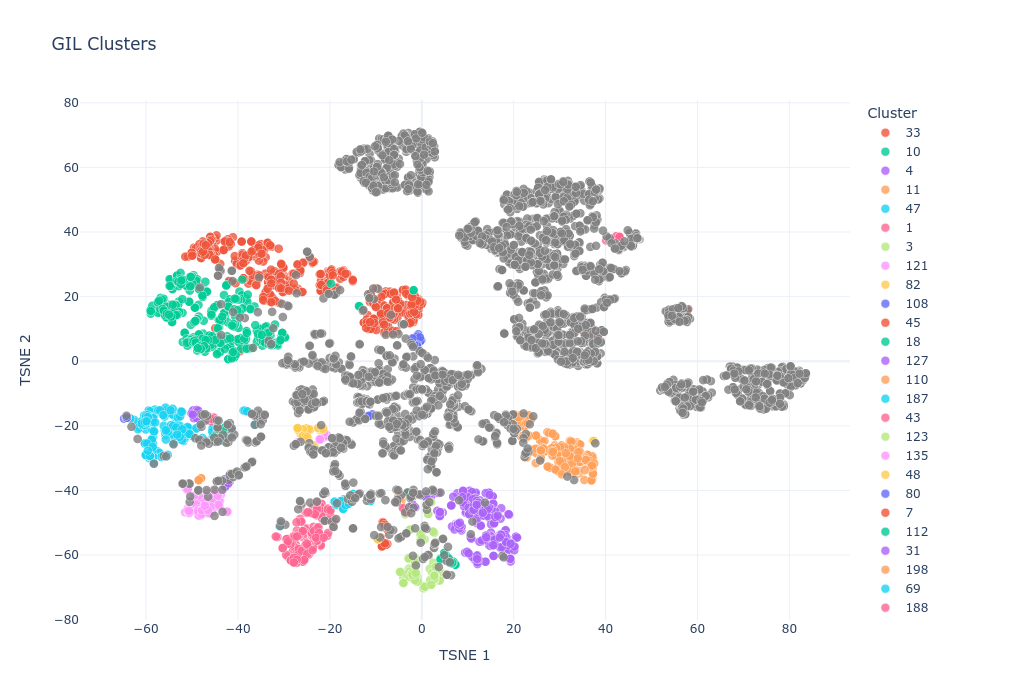

In [24]:
import plotly.express as px


# --- Step 1: Create a color column that handles NaN explicitly ---
tsne_res['color'] = tsne_res['clusters'].fillna('NaN')   # turn NaN into a string category
tsne_res['color'] = tsne_res['color'].astype(str)        # ensure everything is string

# --- NEW: Compute desired legend order (largest cluster → smallest, NaN last) ---
cluster_sizes = tsne_res['color'].value_counts()         # Series: index=cluster, value=count
# Sort known clusters by size descending, then force 'NaN' to the end
legend_order = (
    cluster_sizes.drop('NaN', errors='ignore')           # drop NaN if present
                 .sort_values(ascending=False)           # largest first
                 .index
                 .tolist() 
    + ['NaN']                                             # NaN always last
)

# --- Step 2: Build the scatter plot ---
fig = px.scatter(
    tsne_res,
    x=0,
    y=1,
    color='color',
    color_discrete_map={
        'NaN': 'grey',
        # optionally add fixed colors here
    },
    hover_data={
        'color': True,
        'junction_aa': True,
        'v_call': True,
        'j_call': True,
    },
    category_orders={'color': legend_order},   # <<< THIS IS THE KEY LINE
    title='GIL Clusters',
    labels={'0': 'TSNE 1', '1': 'TSNE 2', 'color': 'Cluster'},
)

fig.update_traces(
    hovertemplate=(
        "<b>Cluster</b>: %{customdata[0]}<br>"
        "<b>Junction AA</b>: %{customdata[1]}<br>"
        "<b>V call</b>: %{customdata[2]}<br>"
        "<b>J call</b>: %{customdata[3]}<br>"
        "<extra></extra>"
    ),
    marker=dict(size=9, opacity=0.8, line=dict(width=0.5, color='white'))
)

# --- Make the "NaN" legend entry look nice ---
fig.for_each_trace(lambda t: t.update(name='NaN (unassigned)') if t.name == 'NaN' else t)

# Optional styling
fig.update_layout(
    legend_title_text='Cluster',
    template='plotly_white',
    width=900,
    height=700,
    legend={'traceorder': 'normal'}   # ensures category_orders is respected
)

fig.write_html(
    "gil_cluster_plotting_test.html",
    include_plotlyjs='cdn',
    config={'displaylogo': False,
            'toImageButtonOptions': {'format': 'svg', 'filename': 'plot'}}
)

fig.show()